# Briefsummary Parser

Our high throughput dft code returns text files with a summary of calculation results. Here we convert this text files to a pandas dataframe containing all the information

We use some tools developed for this propose alone. The module `Featurizer` parses the strings in the `briefsummary.dat` files and recreates information of each sample as magnetic configuration, lattice occupation signatures, etc.

# TODO: calculate formation energies and put them in the df !

In [1]:
from Tools.DatasetTools.Commoms import *
#sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
dataset = 'Fe-Mo' # 'Cr-Co-W',  'Fe-Mo'
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

# Load Brief Summary

In [2]:
BS = StructSummaryParser(dataset, ForceMakeBS=True).BriefSummary

need to create briefsummary list
creating new list of briefsummaries


In [3]:
BS[BS.index.str.contains('R')]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,255.953497,14.436090,Fe_pv,Mo_sv,15,38,53
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,228.424823,15.771180,Fe_pv,Mo_sv,8,45,53
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,230.367641,15.923339,Fe_pv,Mo_sv,6,47,53
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,247.124292,15.195143,Fe_pv,Mo_sv,9,44,53
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,240.778599,15.948587,Fe_pv,Mo_sv,3,50,53
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,238.852230,16.207674,Fe_pv,Mo_sv,1,52,53
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,238.808096,16.315439,Mo_sv,,53,0,53
Mo_sv53.R-Mo.FM,bulk R-Mo.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,238.811481,16.315255,Mo_sv,,53,0,53
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,274.081057,10.496832,Fe_pv,,53,0,53
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,273.598211,10.590332,Fe_pv,Mo_sv,52,1,53


In [4]:
BS[BS.index.str.contains('R-AAAAAAAABBB.NM')]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,bulk R-AAAAAAAABBB,11.758856 A,-8.881292,276.280981 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,276.280981,11.758856,Fe_pv,Mo_sv,39,14,53


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [5]:
Features  = Featurizer(BS)

In [6]:
if 'Fe' in dataset:
    ground_states = Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [7]:
ground_states

{('Fe_pv', 'FM', 'bcc'): -8.254843,
 ('Fe_pv', 'NM', 'hcp'): -8.184069,
 ('Fe_pv', 'NM', 'fcc'): -8.104999,
 ('Mo_sv', 'FM', 'bcc'): -10.932791,
 ('Mo_sv', 'NM', 'bcc'): -10.932826}

I want to see how different the machine learning part can be if the ground state for the non magnetic part is taken as the hcp or the fcc.

In [8]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'hcp')]
if 'Mo' in dataset:
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [9]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'fcc')]
if 'Mo' in dataset:
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [10]:
this_ground_states

{('Fe_pv', 'FM'): -8.254843,
 ('Fe_pv', 'NM'): -8.184069,
 ('Mo_sv', 'FM'): -10.932791,
 ('Mo_sv', 'NM'): -10.932826}

In [11]:
BS['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv', 'FM', 'bcc')]})

In [12]:
BS['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)

In [13]:
BS['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

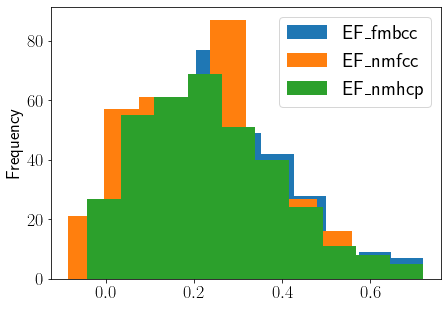

In [14]:
fig, ax =  plt.subplots()
for target_case in ['EF_fmbcc', 'EF_nmfcc', 'EF_nmhcp']:
    ax = BS[target_case].plot.hist(ax=ax, label = target_case)
ax.legend()

In [15]:
#BS.to_pickle(f'{dataset}/ParsedBriefsummary.pkl')

# Magnetic vs Non Magnetic

In [16]:
target_case = 'EF_nmhcp'

In [17]:
EFFM = BS[target_case][Features.Mag == 'FM']

In [18]:
EFNM = BS['EF_nmhcp'][Features.Mag == 'NM']

In [19]:
EFFM.index = EFFM.index.str.replace('.FM', '')

In [20]:
EFNM.index = EFNM.index.str.replace('.NM', '')

In [21]:
BS[target_case][Features.StrucNames == 'fcc']

Mo_sv1.fcc.NM          0.421787
Mo_sv4.fcc-cubic.NM    0.419785
Mo_sv4.fcc-cubic.FM    0.418807
Fe_pv1.fcc.FM          0.342800
Fe_pv4.fcc-cubic.FM    0.193968
Fe_pv4.fcc-cubic.NM    0.079070
Name: EF_nmhcp, dtype: float64

In [22]:
BS[target_case][Features.StrucNames == 'bcc']

Mo_sv1.bcc.FM          0.000000
Mo_sv1.bcc.NM          0.000000
Fe_pv1.bcc.NM          0.393396
Fe_pv1.bcc.FM          0.000825
Fe_pv2.bcc-cubic.FM    0.000000
Name: EF_nmhcp, dtype: float64

In [23]:
BS[target_case][Features.StrucNames == 'hcp']

Mo_sv2.hcp.FM             0.436103
Mo_sv2.hcp.NM             0.434970
Fe_pv2.hcp.FM             0.189213
Fe_pv2.hcp.NM             0.000000
Fe_pv1Mo_sv1.hcp-AB.NM    0.259550
Fe_pv1Mo_sv1.hcp-AB.FM    0.294915
Name: EF_nmhcp, dtype: float64

In [24]:
DE_mag  = EFNM - EFFM 

In [25]:
DE_mag[ abs(DE_mag > 0.1)]

Fe_pv1.bcc                   0.392571
Fe_pv10Mo_sv2.C14-ABA        0.122327
Fe_pv10Mo_sv3.mu-BAAAB       0.111849
Fe_pv11Mo_sv2.mu-AAAAB       0.118739
Fe_pv12.C14                  0.165292
Fe_pv12Mo_sv1.mu-BAAAA       0.111532
Fe_pv13.mu                   0.135269
Fe_pv14Mo_sv10.C36-AABAB     0.169230
Fe_pv14Mo_sv10.C36-AABBA     0.106508
Fe_pv18Mo_sv6.C36-AAAAB      0.244699
Fe_pv18Mo_sv6.C36-AAABA      0.163022
Fe_pv1Mo_sv1.B2-AB           0.133134
Fe_pv20Mo_sv4.C36-AABAA      0.124745
Fe_pv24.C36                  0.205400
Fe_pv28Mo_sv2.sigma-BAAAA    0.123620
Fe_pv30.sigma                0.107503
Fe_pv4Mo_sv9.mu-BBAAB        0.120306
Fe_pv5Mo_sv8.mu-ABAAB        0.143368
Fe_pv5Mo_sv8.mu-ABBAA        0.105595
Fe_pv6.C15                   0.260263
Fe_pv6Mo_sv2.A15-AB          0.170837
Fe_pv7Mo_sv6.mu-ABAAA        0.102156
Fe_pv8.A15                   0.154585
Fe_pv8Mo_sv16.C36-AABBB      0.105394
Name: EF_nmhcp, dtype: float64

In [26]:
DE_mag[DE_mag < 0 ]

Fe_pv10Mo_sv14.C36-ABBBA     -0.034093
Fe_pv10Mo_sv14.C36-BBAAB     -0.013983
Fe_pv10Mo_sv14.C36-BBABA     -0.027024
Fe_pv10Mo_sv20.sigma-ABBAB   -0.009727
Fe_pv11Mo_sv2.mu-AAABA       -0.101819
Fe_pv11Mo_sv2.mu-AABAA       -0.020787
Fe_pv12Mo_sv12.C36-BBBAA     -0.029356
Fe_pv12Mo_sv17.chi-BBAB      -0.015458
Fe_pv12Mo_sv17.chi-BBBA      -0.029261
Fe_pv12Mo_sv18.sigma-BABAB   -0.001810
Fe_pv13Mo_sv16.chi-ABBA      -0.031720
Fe_pv14Mo_sv16.sigma-AABAB   -0.004926
Fe_pv16Mo_sv13.chi-BABA      -0.002677
Fe_pv16Mo_sv8.C36-BBAAA      -0.018599
Fe_pv1Mo_sv1.hcp-AB          -0.035365
Fe_pv1Mo_sv12.mu-ABBBB       -0.005354
Fe_pv1Mo_sv28.chi-ABBB       -0.002410
Fe_pv2.hcp                   -0.189213
Fe_pv24Mo_sv5.chi-BBAA       -0.005947
Fe_pv25Mo_sv4.chi-ABAA       -0.005665
Fe_pv2Mo_sv10.C14-BAB        -0.011235
Fe_pv2Mo_sv11.mu-BBBAB       -0.010859
Fe_pv2Mo_sv11.mu-BBBBA       -0.010858
Fe_pv2Mo_sv28.sigma-ABBBB    -0.004686
Fe_pv2Mo_sv6.D0_19-AB3       -0.017667
Fe_pv3Mo_sv1.L12-A3B     

# some graphs for Raw 

In [27]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [28]:
Features.StrucNames

Fe_pv8Mo_sv22.sigma-BBABB.FM     sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM    sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM         C36
Fe_pv3Mo_sv10.mu-ABBBA.FM           mu
Fe_pv5Mo_sv24.chi-AABB.FM          chi
                                 ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM           mu
Fe_pv8Mo_sv22.sigma-BBABB.NM     sigma
Fe_pv1Mo_sv3.L12-AB3.FM            L12
Fe_pv8Mo_sv22.sigma-BBBBA.FM     sigma
Fe_pv10Mo_sv20.sigma-ABBAB.NM    sigma
Length: 351, dtype: object

In [29]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    BS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=BS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [30]:
def do_mag(tag):
    if tag:
        return 'FM'
    else:
        return 'NM'

In [31]:
BS['Mag'] = BS.index.str.contains('FM')

In [32]:
BS['Mag'] = BS['Mag'].map(do_mag)

In [33]:
BS['Mag']

Fe_pv8Mo_sv22.sigma-BBABB.FM     FM
Fe_pv10Mo_sv20.sigma-ABBAB.FM    FM
Fe_pv4Mo_sv20.C36-ABBBB.FM       FM
Fe_pv3Mo_sv10.mu-ABBBA.FM        FM
Fe_pv5Mo_sv24.chi-AABB.FM        FM
                                 ..
Fe_pv3Mo_sv10.mu-ABBBA.NM        NM
Fe_pv8Mo_sv22.sigma-BBABB.NM     NM
Fe_pv1Mo_sv3.L12-AB3.FM          FM
Fe_pv8Mo_sv22.sigma-BBBBA.FM     FM
Fe_pv10Mo_sv20.sigma-ABBAB.NM    NM
Name: Mag, Length: 351, dtype: object

In [34]:
BS['Phase'] = Target_Class

In [35]:
BS = BS[~BS.index.str.contains('delta')]

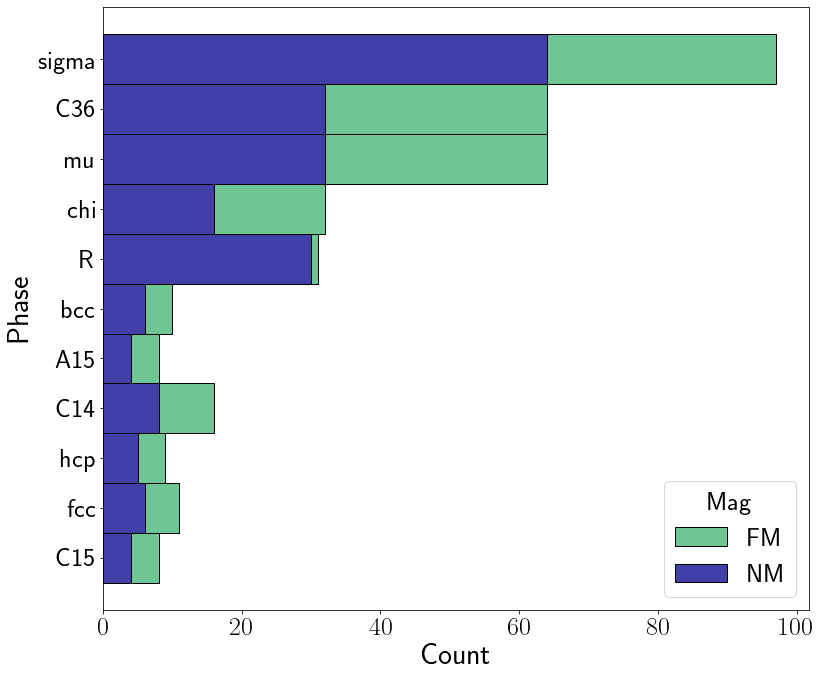

In [36]:
fig, ax = plt.subplots(figsize=(12,10))
sns.histplot(y=BS['Phase'], ax=ax, hue = BS['Mag'], multiple='stack', palette=['mediumseagreen', 'darkblue'], binwidth=0.1)
stack_histogram_file_name = os.path.join(dataset, 'graphs', f'{dataset}_StackCounts_RAW.pdf')
fig.tight_layout()
if not os.path.exists(os.path.dirname(stack_histogram_file_name)):
    os.makedirs(os.path.dirname(stack_histogram_file_name))
fig.savefig(stack_histogram_file_name)